# 加利福尼亚房价回归案例_神经网络_网格搜索

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader

# 1. 加载加利福尼亚房价数据集
california = fetch_california_housing(data_home='./data')
X = california.data
y = california.target

print("原始特征形状:", X.shape)
print("目标形状:", y.shape)

# 2. 划分 train:val:test = 0.6 : 0.2 : 0.2
# 先划分出 train+val 和 test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 再从 train+val 中划分出 val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)  # 0.25 * 0.8 = 0.2

print("训练集:", X_train.shape)
print("验证集:", X_val.shape)
print("测试集:", X_test.shape)

# 3. 标准化（只用训练集数据拟合）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 4. 定义自定义 Dataset 类（内部统一转成 float32 tensor）
class CaliforniaHousingDataset(Dataset):
    def __init__(self, features, targets):
        self.X = torch.tensor(features.astype(np.float32))
        self.y = torch.tensor(targets.astype(np.float32)).unsqueeze(1)  # 调整为[N, 1]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# 5. 创建 Dataset 实例
train_dataset = CaliforniaHousingDataset(X_train_scaled, y_train)
val_dataset = CaliforniaHousingDataset(X_val_scaled, y_val)
test_dataset = CaliforniaHousingDataset(X_test_scaled, y_test)

# 6. 创建 DataLoader
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # 训练集 shuffle
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)  # 验证集不 shuffle
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)  # 测试集不 shuffle

# 简单取一个 batch 看看形状
for X_batch, y_batch in train_loader:
    print("一个 batch 的特征形状:", X_batch.shape)
    print("一个 batch 的标签形状:", y_batch.shape)
    break


原始特征形状: (20640, 8)
目标形状: (20640,)
训练集: (12384, 8)
验证集: (4128, 8)
测试集: (4128, 8)
一个 batch 的特征形状: torch.Size([64, 8])
一个 batch 的标签形状: torch.Size([64, 1])


In [2]:
import torch.nn as nn

# 定义一个包含一层30个神经元的隐藏层和输出层的神经网络
class SimpleRegressor(nn.Module):
    def __init__(self, input_dim):
        """
        初始化模型

        Args:
            input_dim: 输入特征的维度
        """

        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 30),
            nn.ReLU(),
            nn.Linear(30, 1)
        )

    def forward(self, x):
        """
        前向传播

        Args:
            x: 输入特征
        """
        return self.model(x)

In [3]:
# 做一次前向计算进行模型验证

# 假设已定义好 input_dim
input_dim = X_train.shape[1]
model = SimpleRegressor(input_dim)

# 取一个 batch 进行前向传播
model.eval()  # 切换到评估模式
with torch.no_grad():  # 不计算梯度
    X_batch, y_batch = next(iter(val_loader))  # 获取一个 batch
    outputs = model(X_batch)
    print("模型输出形状:", outputs.shape)
    print("真实值形状:", y_batch.shape)

模型输出形状: torch.Size([64, 1])
真实值形状: torch.Size([64, 1])


开始学习率网格搜索
学习率候选值: [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
训练轮数: 50



当前学习率: 0.0001
模型名称: california_housing_regression_lr_0_0001
Trainer 初始化完成
设备: cuda
损失函数: MSELoss()
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
模型名称: california_housing_regression_lr_0_0001
训练集: 12384 个样本, 194 个批次
验证集: 4128 个样本, 65 个批次
早停: 启用 (patience=10, monitor=val_loss, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/california_housing_lr_Search)
学习率 0.0001: 最佳验证损失 = 0.3833 (Epoch 99)

开始绘制训练历史曲线
训练轮数: 100
图像大小: (16, 5)
绘制损失曲线: True
绘制准确率曲线: False


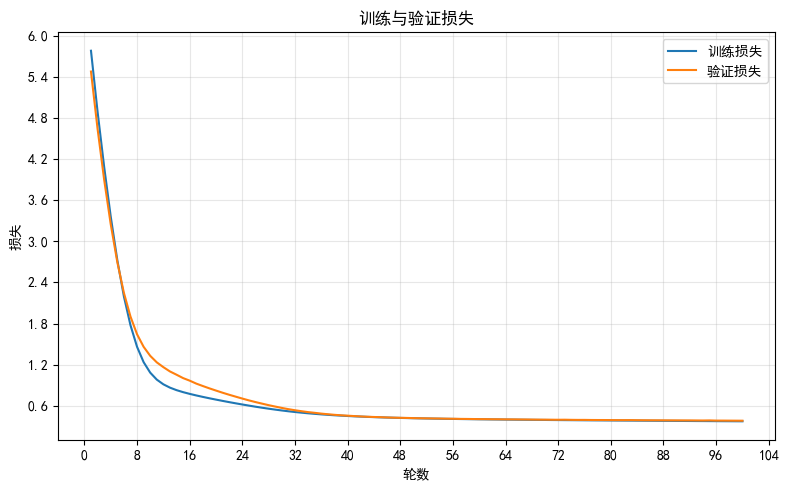

训练历史曲线绘制完成！


当前学习率: 0.0005
模型名称: california_housing_regression_lr_0_0005
Trainer 初始化完成
设备: cuda
损失函数: MSELoss()
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0005
    maximize: False
    weight_decay: 0
)
模型名称: california_housing_regression_lr_0_0005
训练集: 12384 个样本, 194 个批次
验证集: 4128 个样本, 65 个批次
早停: 启用 (patience=10, monitor=val_loss, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/california_housing_lr_Search)
学习率 0.0005: 最佳验证损失 = 0.3444 (Epoch 86)

开始绘制训练历史曲线
训练轮数: 96
图像大小: (16, 5)
绘制损失曲线: True
绘制准确率曲线: False


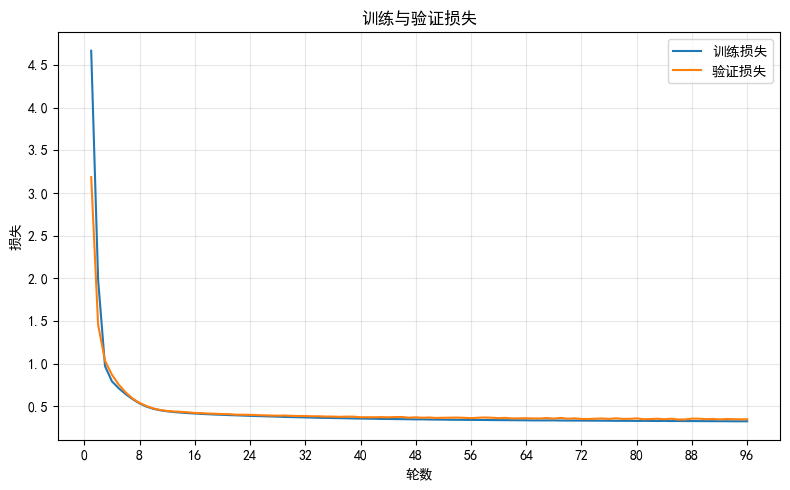

训练历史曲线绘制完成！


当前学习率: 0.001
模型名称: california_housing_regression_lr_0_001
Trainer 初始化完成
设备: cuda
损失函数: MSELoss()
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
模型名称: california_housing_regression_lr_0_001
训练集: 12384 个样本, 194 个批次
验证集: 4128 个样本, 65 个批次
早停: 启用 (patience=10, monitor=val_loss, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/california_housing_lr_Search)
学习率 0.001: 最佳验证损失 = 0.3259 (Epoch 59)

开始绘制训练历史曲线
训练轮数: 69
图像大小: (16, 5)
绘制损失曲线: True
绘制准确率曲线: False


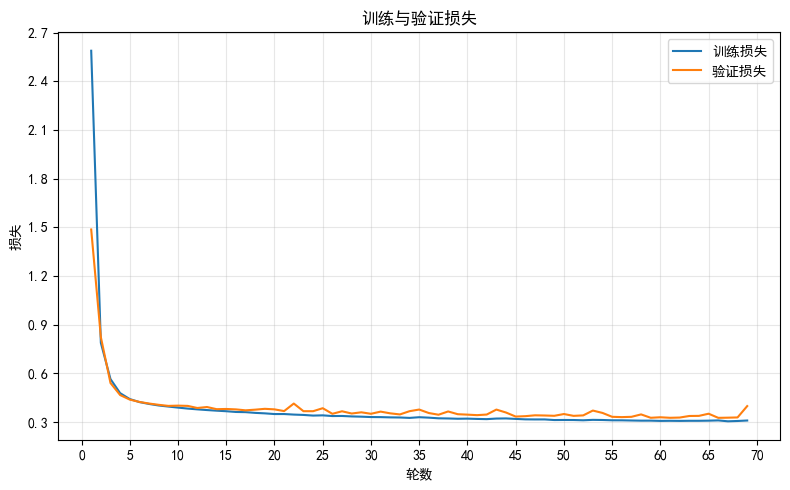

训练历史曲线绘制完成！


当前学习率: 0.005
模型名称: california_housing_regression_lr_0_005
Trainer 初始化完成
设备: cuda
损失函数: MSELoss()
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.005
    maximize: False
    weight_decay: 0
)
模型名称: california_housing_regression_lr_0_005
训练集: 12384 个样本, 194 个批次
验证集: 4128 个样本, 65 个批次
早停: 启用 (patience=10, monitor=val_loss, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/california_housing_lr_Search)
学习率 0.005: 最佳验证损失 = 0.3302 (Epoch 19)

开始绘制训练历史曲线
训练轮数: 29
图像大小: (16, 5)
绘制损失曲线: True
绘制准确率曲线: False


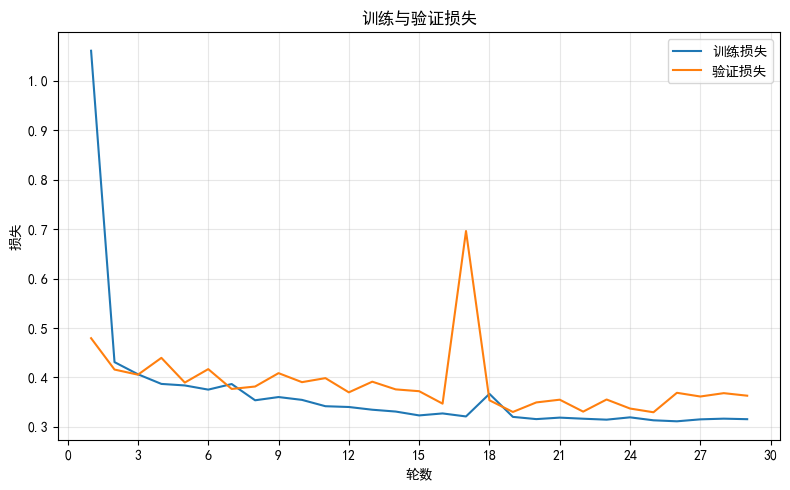

训练历史曲线绘制完成！


当前学习率: 0.01
模型名称: california_housing_regression_lr_0_01
Trainer 初始化完成
设备: cuda
损失函数: MSELoss()
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)
模型名称: california_housing_regression_lr_0_01
训练集: 12384 个样本, 194 个批次
验证集: 4128 个样本, 65 个批次
早停: 启用 (patience=10, monitor=val_loss, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/california_housing_lr_Search)
学习率 0.01: 最佳验证损失 = 0.3178 (Epoch 15)

开始绘制训练历史曲线
训练轮数: 25
图像大小: (16, 5)
绘制损失曲线: True
绘制准确率曲线: False


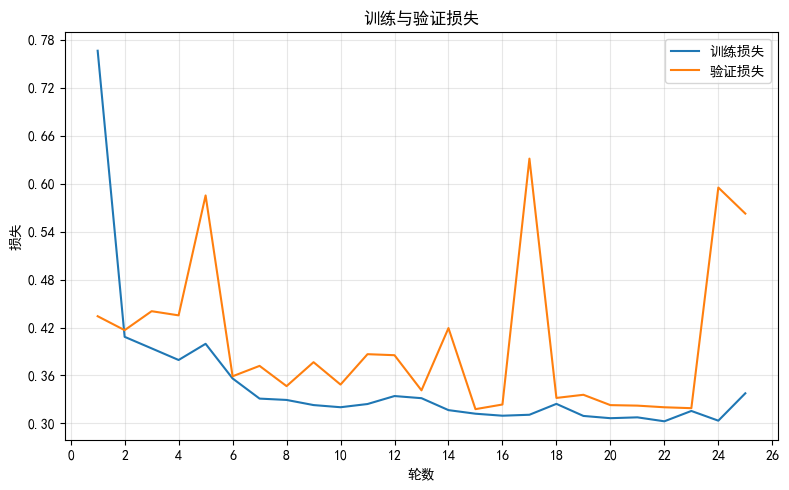

训练历史曲线绘制完成！


当前学习率: 0.05
模型名称: california_housing_regression_lr_0_05
Trainer 初始化完成
设备: cuda
损失函数: MSELoss()
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.05
    maximize: False
    weight_decay: 0
)
模型名称: california_housing_regression_lr_0_05
训练集: 12384 个样本, 194 个批次
验证集: 4128 个样本, 65 个批次
早停: 启用 (patience=10, monitor=val_loss, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/california_housing_lr_Search)
学习率 0.05: 最佳验证损失 = 0.3362 (Epoch 13)

开始绘制训练历史曲线
训练轮数: 23
图像大小: (16, 5)
绘制损失曲线: True
绘制准确率曲线: False


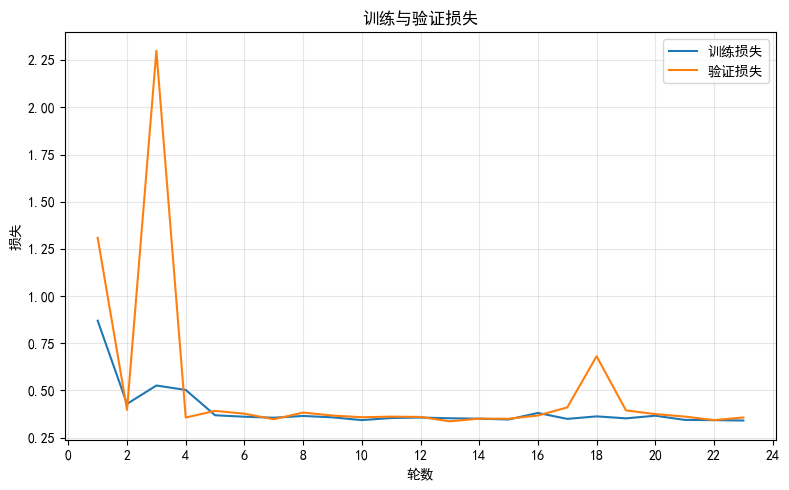

训练历史曲线绘制完成！


当前学习率: 0.1
模型名称: california_housing_regression_lr_0_1
Trainer 初始化完成
设备: cuda
损失函数: MSELoss()
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    weight_decay: 0
)
模型名称: california_housing_regression_lr_0_1
训练集: 12384 个样本, 194 个批次
验证集: 4128 个样本, 65 个批次
早停: 启用 (patience=10, monitor=val_loss, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/california_housing_lr_Search)
学习率 0.1: 最佳验证损失 = 0.3838 (Epoch 9)

开始绘制训练历史曲线
训练轮数: 19
图像大小: (16, 5)
绘制损失曲线: True
绘制准确率曲线: False


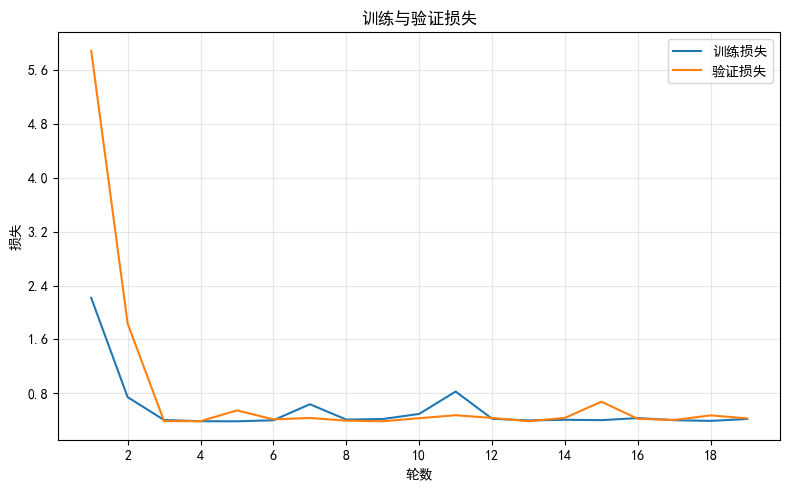

训练历史曲线绘制完成！


当前学习率: 0.5
模型名称: california_housing_regression_lr_0_5
Trainer 初始化完成
设备: cuda
损失函数: MSELoss()
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.5
    maximize: False
    weight_decay: 0
)
模型名称: california_housing_regression_lr_0_5
训练集: 12384 个样本, 194 个批次
验证集: 4128 个样本, 65 个批次
早停: 启用 (patience=10, monitor=val_loss, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/california_housing_lr_Search)
学习率 0.5: 最佳验证损失 = 1.3477 (Epoch 33)

开始绘制训练历史曲线
训练轮数: 43
图像大小: (16, 5)
绘制损失曲线: True
绘制准确率曲线: False


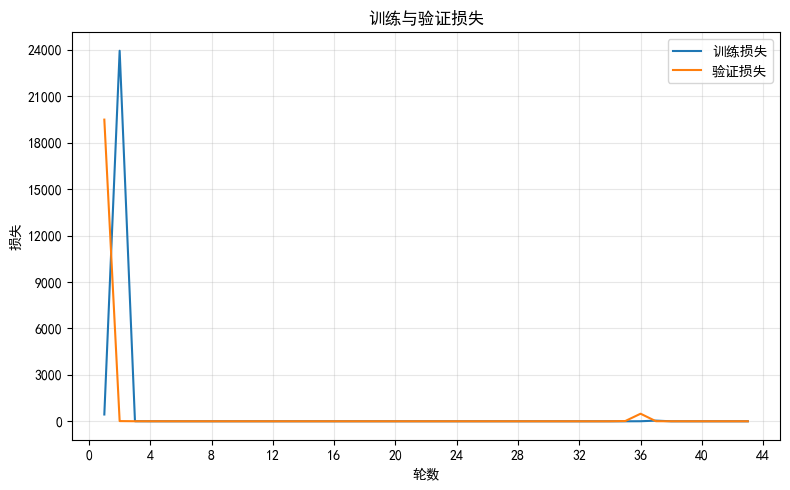

训练历史曲线绘制完成！

学习率网格搜索结果汇总
学习率       最佳验证损失        最佳轮数      最终训练损失        最终验证损失         
--------------------------------------------------------------------------------
0.0100       0.3178             15           0.3377             0.5625            
0.0010       0.3259             59           0.3090             0.3979            
0.0050       0.3302             19           0.3156             0.3631            
0.0500       0.3362             13           0.3404             0.3564            
0.0005       0.3444             86           0.3239             0.3470            
0.0001       0.3833             99           0.3742             0.3828            
0.1000       0.3838             9            0.4180             0.4264            
0.5000       1.3477             33           0.5384             3.1088            

最佳学习率
学习率: 0.01
最佳验证损失: 0.3178
最佳轮数: 15


In [4]:
# 学习率网格搜索

from Train_v4 import Trainer
import torch.nn as nn
import torch.optim as optim
import copy

# 定义学习率候选值
learning_rates = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5]

# 存储每个学习率的结果
results = []

print("=" * 60)
print("开始学习率网格搜索")
print("=" * 60)
print(f"学习率候选值: {learning_rates}")
print(f"训练轮数: 50")
print("=" * 60)
print()

# 对每个学习率进行训练
for lr in learning_rates:
    # 为每个学习率生成唯一的模型名称（将学习率中的点替换为下划线）
    lr_str = str(lr).replace('.', '_')
    model_name = f'california_housing_regression_lr_{lr_str}'
    
    print("\n\n" + "=" * 60)
    print(f"当前学习率: {lr}")
    print(f"模型名称: {model_name}")
    print("=" * 60)
    
    # 1. 创建新的模型实例（每个学习率使用新的模型）
    input_dim = X_train.shape[1]  # 8
    model = SimpleRegressor(input_dim)
    
    # 2. 创建损失函数和优化器（使用当前学习率）
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # 3. 创建 Trainer 实例
    trainer = Trainer(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        early_stopping=True,  # 启用早停
        patience=10,  # 连续10个epoch没有改善则停止
        monitor='val_loss',  # 监控验证损失
        min_delta=0.001,  # 最小改善幅度
        restore_best_weights=True,  # 恢复最佳模型权重
        save_best_model=True,  # 保存最佳模型（每个学习率使用不同的名称）
        save_every_epoch=False,  # 不每个epoch都保存
        save_dir='./checkpoints/california_housing_lr_Search',  # 模型保存目录
        model_name=model_name  # 使用包含学习率的模型名称
    )
    
    # 4. 训练模型（关闭详细输出以减少日志）
    num_epochs = 100
    trainer.train_regression(num_epochs=num_epochs, verbose=False)
    
    # 5. 获取最佳验证损失
    best_val_loss = trainer.best_val_loss
    best_epoch = trainer.best_epoch
    
    # 6. 记录结果
    results.append({
        'lr': lr,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'final_train_loss': trainer.train_losses[-1] if trainer.train_losses else None,
        'final_val_loss': trainer.val_losses[-1] if trainer.val_losses else None
    })
    
    print(f"学习率 {lr}: 最佳验证损失 = {best_val_loss:.4f} (Epoch {best_epoch})")
    trainer.plot_history(plot_loss=True, plot_acc=False)

# 显示所有结果
print("\n" + "=" * 60)
print("学习率网格搜索结果汇总")
print("=" * 60)
print(f"{'学习率':<9} {'最佳验证损失':<13} {'最佳轮数':<9} {'最终训练损失':<13} {'最终验证损失':<15}")
print("-" * 80)

# 按最佳验证损失排序
results_sorted = sorted(results, key=lambda x: x['best_val_loss'])

for result in results_sorted:
    print(f"{result['lr']:<12.4f} {result['best_val_loss']:<18.4f} {result['best_epoch']:<12} "
          f"{result['final_train_loss']:<18.4f} {result['final_val_loss']:<18.4f}")

# 找到最佳学习率
best_result = results_sorted[0]
print("\n" + "=" * 60)
print("最佳学习率")
print("=" * 60)
print(f"学习率: {best_result['lr']}")
print(f"最佳验证损失: {best_result['best_val_loss']:.4f}")
print(f"最佳轮数: {best_result['best_epoch']}")
print("=" * 60)


使用网格搜索得到的最佳学习率: 0.01

使用最佳学习率进行最终训练
模型参数总数: 301
Trainer 初始化完成
设备: cuda
损失函数: MSELoss()
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)
模型名称: california_housing_regression_best
训练集: 12384 个样本, 194 个批次
验证集: 4128 个样本, 65 个批次
早停: 启用 (patience=10, monitor=val_loss, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/california_housing)

开始训练模型（回归任务）
训练轮数: 100
训练集: 12384 个样本, 194 个批次
验证集: 4128 个样本, 65 个批次
设备: cuda
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)
早停: 启用 (patience=10, monitor=val_loss, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/california_housing)

Epoch [1/100], Train Loss: 0.8077, Val Loss: 0.4996
Epoch [2/100], Train Los

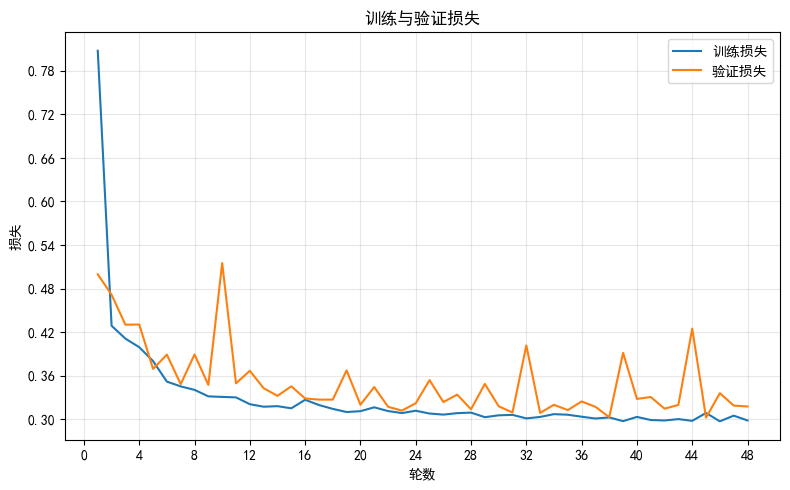

训练历史曲线绘制完成！

最终训练和评估完成！
使用学习率: 0.01
最终验证损失: 0.3175
最终测试损失: 0.3102


In [5]:
# 使用最佳学习率进行最终训练和评估

# 从网格搜索结果中获取最佳学习率
# 如果上面的 cell 已经运行，best_result 变量应该存在
# 如果没有运行上面的 cell，可以手动设置最佳学习率
try:
    best_lr = best_result['lr']
    print(f"使用网格搜索得到的最佳学习率: {best_lr}")
except NameError:
    # 如果没有运行网格搜索，使用默认值
    best_lr = 0.001
    print(f"未找到网格搜索结果，使用默认学习率: {best_lr}")
    print("提示：请先运行上面的学习率网格搜索 cell")

print("\n" + "=" * 60)
print("使用最佳学习率进行最终训练")
print("=" * 60)

# 1. 创建新的模型实例
input_dim = X_train.shape[1]  # 8
model = SimpleRegressor(input_dim)

# 计算模型参数数量
total_params = sum(p.numel() for p in model.parameters())
print(f"模型参数总数: {total_params:,}")

# 2. 创建损失函数和优化器（使用最佳学习率）
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=best_lr)

# 3. 创建 Trainer 实例
trainer = Trainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    early_stopping=True,  # 启用早停
    patience=10,  # 连续10个epoch没有改善则停止
    monitor='val_loss',  # 监控验证损失
    min_delta=0.001,  # 最小改善幅度
    restore_best_weights=True,  # 恢复最佳模型权重
    save_best_model=True,  # 保存最佳模型
    save_every_epoch=False,  # 不每个epoch都保存
    save_dir='./checkpoints/california_housing',  # 模型保存目录
    model_name='california_housing_regression_best'  # 模型名称
)

# 4. 训练模型
num_epochs = 100  # 设置最大训练轮数
trainer.train_regression(num_epochs=num_epochs, verbose=True)

# 5. 评估模型（验证集）
print("\n" + "=" * 60)
print("评估模型 - 验证集")
print("=" * 60)
val_loss = trainer.evaluating_regression(val_loader, verbose=True)

# 6. 评估模型（测试集）
print("\n" + "=" * 60)
print("评估模型 - 测试集")
print("=" * 60)
test_loss = trainer.evaluating_regression(test_loader, verbose=True)

# 7. 绘制训练历史曲线（只绘制损失，不绘制准确率）
print("\n" + "=" * 60)
print("绘制训练历史曲线")
print("=" * 60)
trainer.plot_history(plot_loss=True, plot_acc=False)

print("\n" + "=" * 60)
print("最终训练和评估完成！")
print("=" * 60)
print(f"使用学习率: {best_lr}")
print(f"最终验证损失: {val_loss:.4f}")
print(f"最终测试损失: {test_loss:.4f}")
print("=" * 60)
